# Social Media

Social media platforms play a central role in daily digital behavior, influencing how users communicate, create content, and interact with others. Understanding the relationship between time spent on social media and user activity levels is essential for analyzing engagement patterns and behavioral trends.

This project aims to examine whether increased time spent on social media platforms leads to higher levels of user activity. Activity is measured through content creation (posts), interactions (likes given), and communication behavior (messages sent). By analyzing usage data across multiple platforms, this study seeks to identify patterns, correlations, and behavioral differences among users.

## Main Research Question:
Is there a relationship between time spent on social media platforms and user activity levels?

## Sub-Research Questions:
-Is there a positive correlation between total daily usage time (total_minutes) and the number of posts created per day (posts_per_day)?

-Do users who spend more time on social media give more likes (likes_given_per_day)?

-Does higher daily usage time lead to increased messaging activity (messages_sent_per_day)?

-Does the relationship between time spent and activity differ across platforms?

## Tools and Analytical Techniques:
The analysis was conducted using Python, primarily with the Pandas library for data manipulation and transformation. Matplotlib was used for data visualization.

The following analytical techniques were applied:
-Data preprocessing, including datetime conversion and feature creation
-Aggregation using groupby() to analyze activity at user and platform levels
-Descriptive statistics (mean, median, standard deviation)
-Correlation analysis to examine relationships between time spent and activity metrics
-User segmentation based on total usage time
-Time-based analysis through monthly and weekly aggregation
-Multiple visualization techniques such as line charts, bar charts, box plots, histograms, and correlation matrices

These tools and techniques enabled a structured exploration of the relationship between time spent on social media platforms and user activity levels.

## Data Description
The files are in CSV format.
There are 5 tables: Users, Platforms, Gender, Daily_usage and Posts.
Each table is represented in a different data frame.

Posts contains post-level engagement data.
Daily_Usage contains aggregated daily activity per user and platform.
Key variables include total_minutes, posts_per_day, likes_given_per_day, and messages_sent_per_day.

In [1]:
import pandas as pd
daily=pd.read_csv(r"C:\Users\mora1\Desktop\Data Analysis\פרויקט שלישי\Daily_Usage.csv")
gender=pd.read_csv(r"C:\Users\mora1\Desktop\Data Analysis\פרויקט שלישי\Genders.csv")
platform=pd.read_csv(r"C:\Users\mora1\Desktop\Data Analysis\פרויקט שלישי\Platforms.csv")
posts=pd.read_csv(r"C:\Users\mora1\Desktop\Data Analysis\פרויקט שלישי\Posts.csv")
users=pd.read_csv(r"C:\Users\mora1\Desktop\Data Analysis\פרויקט שלישי\Users.csv")

In [2]:
daily.shape

(300, 9)

In [3]:
daily.head()

,usage_id,user_id,platform_id,usage_date,sessions_per_day,total_minutes,posts_per_day,likes_given_per_day,messages_sent_per_day
0,1,13,6,2025-03-27,1,35,0,17,6
1,2,6,5,2025-04-03,3,78,0,31,11
2,3,16,7,2025-03-24,4,101,1,34,2
3,4,14,5,2025-04-19,5,69,0,36,14
4,5,2,5,2025-02-14,1,71,0,26,12


In [4]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   usage_id               300 non-null    int64 
 1   user_id                300 non-null    int64 
 2   platform_id            300 non-null    int64 
 3   usage_date             300 non-null    object
 4   sessions_per_day       300 non-null    int64 
 5   total_minutes          300 non-null    int64 
 6   posts_per_day          300 non-null    int64 
 7   likes_given_per_day    300 non-null    int64 
 8   messages_sent_per_day  300 non-null    int64 
dtypes: int64(8), object(1)
memory usage: 21.2+ KB


In [5]:
gender.shape

(3, 2)

In [6]:
gender.head()

,gender_id,gender_name
0,2,Female
1,1,Male
2,3,Non-binary


In [7]:
gender.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   gender_id    3 non-null      int64 
 1   gender_name  3 non-null      object
dtypes: int64(1), object(1)
memory usage: 180.0+ bytes


In [8]:
platform.shape

(7, 3)

In [9]:
platform.head()

,platform_id,platform_name,category
0,1,Instagram,Photo sharing
1,2,TikTok,Video
2,3,Facebook,Social network
3,4,LinkedIn,Professional
4,5,Telegram,Messaging


In [10]:
platform.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   platform_id    7 non-null      int64 
 1   platform_name  7 non-null      object
 2   category       7 non-null      object
dtypes: int64(1), object(2)
memory usage: 300.0+ bytes


In [11]:
posts.shape

(300, 7)

In [12]:
posts.head()

,post_id,user_id,platform_id,post_datetime,content,likes_count,comments_count
0,1,12,3,2025-03-18T17:20:00,Quick update,52,11
1,2,16,1,2025-02-05T18:20:00,Daily moments,45,7
2,3,10,1,2025-03-08T15:00:00,Sharing an article,111,15
3,4,20,2,2025-02-10T12:50:00,Photo dump,575,106
4,5,10,2,2025-02-23T20:30:00,Mini vlog,117,13


In [13]:
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   post_id         300 non-null    int64 
 1   user_id         300 non-null    int64 
 2   platform_id     300 non-null    int64 
 3   post_datetime   300 non-null    object
 4   content         300 non-null    object
 5   likes_count     300 non-null    int64 
 6   comments_count  300 non-null    int64 
dtypes: int64(5), object(2)
memory usage: 16.5+ KB


In [14]:
users.shape

(20, 7)

In [15]:
users.head()

,user_id,full_name,age,date_of_birth,email,gender_id,country
0,1,Noa Cohen,27,15/04/1998,noa@gmail.com,2,Israel
1,2,Daniel Levi,21,10/09/2003,daniel@gmail.com,3,Israel
2,3,Alex Green,28,22/01/1997,alex@gmail.com,3,United States
3,4,Yossi Bar,27,02/11/1998,yossi@gmail.com,1,Germany
4,5,Lior Shalev,21,18/03/2003,lior@gmail.com,3,United Kingdom


In [16]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   user_id        20 non-null     int64 
 1   full_name      20 non-null     object
 2   age            20 non-null     int64 
 3   date_of_birth  20 non-null     object
 4   email          20 non-null     object
 5   gender_id      20 non-null     int64 
 6   country        20 non-null     object
dtypes: int64(3), object(4)
memory usage: 1.2+ KB


## Data Cleaning and Preprocessing
In this section, date conversion, missing value checks, and feature creation were performed.  
Duplicate records were examined and removed to ensure data consistency.

To enrich the analysis, the daily usage and posts datasets were merged with the platforms and users datasets.  
This allowed platform-level and user-level analysis beyond numerical IDs.

Two additional variables were created:
-Minutes per session – calculated to examine whether users who spend more time in each session tend to be more active.
-Activity score – created to quantify overall user activity by combining posts, likes given, and messages sent into a single metric.

In [17]:
posts['post_datetime'] = pd.to_datetime(posts['post_datetime'])
daily['usage_date'] = pd.to_datetime(daily['usage_date'])
users['date_of_birth'] = pd.to_datetime(users['date_of_birth'])

C:\Users\mora1\AppData\Local\Temp\ipykernel_17532\3418179589.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  users['date_of_birth'] = pd.to_datetime(users['date_of_birth'])


In [18]:
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   post_id         300 non-null    int64         
 1   user_id         300 non-null    int64         
 2   platform_id     300 non-null    int64         
 3   post_datetime   300 non-null    datetime64[ns]
 4   content         300 non-null    object        
 5   likes_count     300 non-null    int64         
 6   comments_count  300 non-null    int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 16.5+ KB


In [19]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   usage_id               300 non-null    int64         
 1   user_id                300 non-null    int64         
 2   platform_id            300 non-null    int64         
 3   usage_date             300 non-null    datetime64[ns]
 4   sessions_per_day       300 non-null    int64         
 5   total_minutes          300 non-null    int64         
 6   posts_per_day          300 non-null    int64         
 7   likes_given_per_day    300 non-null    int64         
 8   messages_sent_per_day  300 non-null    int64         
dtypes: datetime64[ns](1), int64(8)
memory usage: 21.2 KB


In [20]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   user_id        20 non-null     int64         
 1   full_name      20 non-null     object        
 2   age            20 non-null     int64         
 3   date_of_birth  20 non-null     datetime64[ns]
 4   email          20 non-null     object        
 5   gender_id      20 non-null     int64         
 6   country        20 non-null     object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 1.2+ KB


In [21]:
posts=posts.drop_duplicates()
daily=daily.drop_duplicates()
users=users.drop_duplicates()
gender=gender.drop_duplicates()
platform=platform.drop_duplicates()

In [22]:
posts.isna().sum()

post_id           0
user_id           0
platform_id       0
post_datetime     0
content           0
likes_count       0
comments_count    0
dtype: int64

In [23]:
daily.isna().sum()

usage_id                 0
user_id                  0
platform_id              0
usage_date               0
sessions_per_day         0
total_minutes            0
posts_per_day            0
likes_given_per_day      0
messages_sent_per_day    0
dtype: int64

In [24]:
users.isna().sum()

user_id          0
full_name        0
age              0
date_of_birth    0
email            0
gender_id        0
country          0
dtype: int64

In [25]:
gender.isna().sum()

gender_id      0
gender_name    0
dtype: int64

In [26]:
platform.isna().sum()

platform_id      0
platform_name    0
category         0
dtype: int64

In [27]:
daily = daily.merge(platform, on="platform_id", how="left")
daily = daily.merge(users, on="user_id", how="left")
posts = posts.merge(platform, on="platform_id", how="left")
daily = daily.merge(users, on="user_id", how="left")

In [28]:
daily["minutes_per_session"] = daily["total_minutes"] / daily["sessions_per_day"]
daily["activity_score"] = (
    daily["posts_per_day"] +
    daily["likes_given_per_day"] +
    daily["messages_sent_per_day"]
)

After performing the preprocessing steps, the datasets were checked for missing values using isna().sum(), and no missing values were found. Therefore, no additional handling such as imputation or row removal was required.

Duplicate records were also checked and removed using drop_duplicates() to ensure data consistency.

Finally, the datasets were merged using merge() in order to combine usage data with platform and user information. This allowed further analysis by platform and user characteristics rather than relying only on numerical IDs.

## Descriptive Statistics
In this section, descriptive statistics are presented in order to understand the overall distribution of the main variables before running deeper analysis.  

The goal is to summarize central tendency and variability using mean, median and standard deviation and to identify extreme values (minimum and maximum) that may represent unusual user behavior.

The analysis focuses on the key variables related to the research question:
- total_minutes (daily time spent on the platform)
- posts_per_day, likes_given_per_day, messages_sent_per_day (daily activity metrics)

In addition, descriptive statistics are examined by platform and by time period (month) to compare patterns across categories.

In [29]:
daily.describe()

,usage_id,user_id,platform_id,usage_date,sessions_per_day,total_minutes,posts_per_day,likes_given_per_day,messages_sent_per_day,age_x,date_of_birth_x,gender_id_x,age_y,date_of_birth_y,gender_id_y,minutes_per_session,activity_score
count,300.000000,300.000000,300.000000,300,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300,300.000000,300.000000,300,300.000000,300.000000,300.000000
mean,150.500000,10.743333,4.123333,2025-03-02 08:38:24,2.07000,78.793333,0.486667,34.163333,4.880000,25.916667,1999-05-25 07:26:24,2.013333,25.916667,1999-05-25 07:26:24,2.013333,49.004393,39.530000
min,1.000000,1.000000,1.000000,2025-01-02 00:00:00,1.00000,6.000000,0.000000,2.000000,0.000000,19.000000,1991-09-03 00:00:00,1.000000,19.000000,1991-09-03 00:00:00,1.000000,6.000000,5.000000
25%,75.750000,6.000000,2.000000,2025-01-30 18:00:00,1.00000,53.000000,0.000000,21.750000,3.000000,23.000000,1996-12-21 00:00:00,1.000000,23.000000,1996-12-21 00:00:00,1.000000,27.000000,27.000000
50%,150.500000,11.000000,4.000000,2025-03-02 00:00:00,1.00000,74.500000,0.000000,30.000000,4.000000,27.000000,1998-11-02 00:00:00,2.000000,27.000000,1998-11-02 00:00:00,2.000000,41.833333,36.000000
75%,225.250000,16.000000,6.000000,2025-03-30 00:00:00,3.00000,101.250000,1.000000,44.000000,6.000000,29.000000,2002-07-09 12:00:00,3.000000,29.000000,2002-07-09 12:00:00,3.000000,63.000000,49.250000
max,300.000000,20.000000,7.000000,2025-04-30 00:00:00,8.00000,188.000000,4.000000,98.000000,17.000000,34.000000,2006-02-14 00:00:00,3.000000,34.000000,2006-02-14 00:00:00,3.000000,170.000000,100.000000
std,86.746758,5.730642,1.986945,NaN,1.42309,35.111537,0.738222,17.460801,3.154696,4.149754,NaN,0.801225,4.149754,NaN,0.801225,29.179224,17.550379


In [30]:
posts.describe()

,post_id,user_id,platform_id,post_datetime,likes_count,comments_count
count,300.000000,300.000000,300.000000,300,300.000000,300.000000
mean,150.500000,10.940000,3.076667,2025-03-06 02:01:08,77.843333,11.596667
min,1.000000,1.000000,1.000000,2025-01-01 08:50:00,0.000000,0.000000
25%,75.750000,6.000000,1.750000,2025-02-06 15:27:30,31.000000,3.750000
50%,150.500000,11.000000,2.000000,2025-03-10 18:25:00,61.000000,9.000000
75%,225.250000,16.000000,4.000000,2025-04-03 00:27:30,91.250000,13.000000
max,300.000000,20.000000,7.000000,2025-04-30 23:40:00,595.000000,124.000000
std,86.746758,5.676013,1.936480,NaN,93.942978,16.435767


In [31]:
daily.loc[daily["total_minutes"].min()]

usage_id                                   7
user_id                                    6
platform_id                                4
usage_date               2025-03-16 00:00:00
sessions_per_day                           1
total_minutes                             53
posts_per_day                              1
likes_given_per_day                       25
messages_sent_per_day                      4
platform_name                       LinkedIn
category                        Professional
full_name_x                          Tal Mor
age_x                                     24
date_of_birth_x          2001-06-25 00:00:00
email_x                        tal@gmail.com
gender_id_x                                2
country_x                             Brazil
full_name_y                          Tal Mor
age_y                                     24
date_of_birth_y          2001-06-25 00:00:00
email_y                        tal@gmail.com
gender_id_y                                2
country_y 

In [32]:
daily.loc[daily["total_minutes"].max()]

usage_id                                 189
user_id                                   18
platform_id                                6
usage_date               2025-02-05 00:00:00
sessions_per_day                           1
total_minutes                             31
posts_per_day                              1
likes_given_per_day                       15
messages_sent_per_day                      1
platform_name                        Spotify
category                               Music
full_name_x                       Amir Cohen
age_x                                     31
date_of_birth_x          1994-02-28 00:00:00
email_x                       amir@gmail.com
gender_id_x                                1
country_x                             Norway
full_name_y                       Amir Cohen
age_y                                     31
date_of_birth_y          1994-02-28 00:00:00
email_y                       amir@gmail.com
gender_id_y                                1
country_y 

In [33]:
daily.loc[daily["posts_per_day"].min()]

usage_id                                   1
user_id                                   13
platform_id                                6
usage_date               2025-03-27 00:00:00
sessions_per_day                           1
total_minutes                             35
posts_per_day                              0
likes_given_per_day                       17
messages_sent_per_day                      6
platform_name                        Spotify
category                               Music
full_name_x                       Sara Cohen
age_x                                     23
date_of_birth_x          2002-08-04 00:00:00
email_x                       sara@gmail.com
gender_id_x                                2
country_x                              Spain
full_name_y                       Sara Cohen
age_y                                     23
date_of_birth_y          2002-08-04 00:00:00
email_y                       sara@gmail.com
gender_id_y                                2
country_y 

In [34]:
daily.loc[daily["posts_per_day"].max()]

usage_id                                   5
user_id                                    2
platform_id                                5
usage_date               2025-02-14 00:00:00
sessions_per_day                           1
total_minutes                             71
posts_per_day                              0
likes_given_per_day                       26
messages_sent_per_day                     12
platform_name                       Telegram
category                           Messaging
full_name_x                      Daniel Levi
age_x                                     21
date_of_birth_x          2003-09-10 00:00:00
email_x                     daniel@gmail.com
gender_id_x                                3
country_x                             Israel
full_name_y                      Daniel Levi
age_y                                     21
date_of_birth_y          2003-09-10 00:00:00
email_y                     daniel@gmail.com
gender_id_y                                3
country_y 

The descriptive statistics show that the minimum daily usage time in the dataset is 53 minutes, while the maximum reaches about 180 minutes. This indicates that some users spend significantly more time on social media than others.

For content creation, the number of posts per day ranges from 0 to 4. This suggests that many users consume content without necessarily creating posts.

Overall, the descriptive statistics indicate that user activity levels vary considerably, with some users showing relatively low engagement while others demonstrate higher activity across likes, posts, and messaging.

## Advanced Analysis

In this section, aggregation techniques were used to explore patterns in user activity across different dimensions.

The data was grouped by platform, user, and time (month) in order to identify differences in usage behavior and activity levels.

Average values of key variables such as total_minutes, posts_per_day, likes_given_per_day, and messages_sent_per_day were compared across platforms and users.

In addition, the posts dataset was analyzed to examine posting activity and identify the most active users based on the number of posts created.

These aggregations help reveal how user engagement varies between platforms and over time.

In [35]:
daily.groupby("platform_id")[["total_minutes","posts_per_day","likes_given_per_day","messages_sent_per_day"]].mean()

,total_minutes,posts_per_day,likes_given_per_day,messages_sent_per_day
platform_id,,,,
1,99.651163,0.581395,43.302326,3.697674
2,136.756757,0.756757,60.945946,4.189189
3,75.218750,0.250000,32.218750,4.093750
4,48.877551,0.387755,20.612245,3.775510
5,66.108696,0.369565,29.217391,10.195652
6,54.433962,0.320755,22.773585,3.830189
7,89.125000,0.800000,38.500000,4.050000


In [36]:
daily.groupby("user_id")[["total_minutes","posts_per_day","likes_given_per_day","messages_sent_per_day"]].mean()

,total_minutes,posts_per_day,likes_given_per_day,messages_sent_per_day
user_id,,,,
1,75.000000,0.266667,33.466667,4.400000
2,76.937500,0.437500,33.437500,4.312500
3,63.777778,0.555556,27.555556,5.888889
4,81.875000,0.375000,31.625000,4.625000
5,64.818182,0.454545,29.454545,5.454545
6,77.363636,0.272727,35.272727,5.090909
7,85.100000,0.850000,36.100000,4.800000
8,104.117647,0.470588,49.941176,4.411765
9,71.235294,0.411765,32.764706,5.588235


In [37]:
daily["month"] = daily["usage_date"].dt.month

In [38]:
daily.groupby("month")[["total_minutes","posts_per_day","likes_given_per_day","messages_sent_per_day"]].mean()

,total_minutes,posts_per_day,likes_given_per_day,messages_sent_per_day
month,,,,
1,69.128205,0.461538,30.576923,4.756410
2,75.818182,0.469697,32.833333,5.121212
3,75.244186,0.476744,32.569767,4.976744
4,96.728571,0.542857,41.371429,4.671429


In [39]:
posts.groupby("user_id")["post_id"].count().sort_values(ascending=False).head()

user_id
10    23
18    19
11    18
19    18
17    17
Name: post_id, dtype: int64

The results show that some users are significantly more active in creating content than others, indicating differences in content creation behavior among users.

## Visualization

In this section, several visualization techniques were used to explore patterns in the data and support the research questions.

Different chart types were used to examine the relationship between time spent on social media platforms and user activity levels, as well as differences between platforms and trends over time.

The following visualizations were created:
1. Histogram – shows the distribution of daily usage time among users.
2. Boxplot – displays the distribution of usage time across different levels of posting activity (posts per day).
3. Bar chart – compares average usage time across different platforms.
4. Line chart – shows changes in usage patterns over time.
5. Heatmap – displays the correlation between usage time and activity metrics.

In [40]:
import seaborn as sb
import matplotlib.pyplot as plt

sb.set_style("whitegrid")
project_color = "#FCCC63"

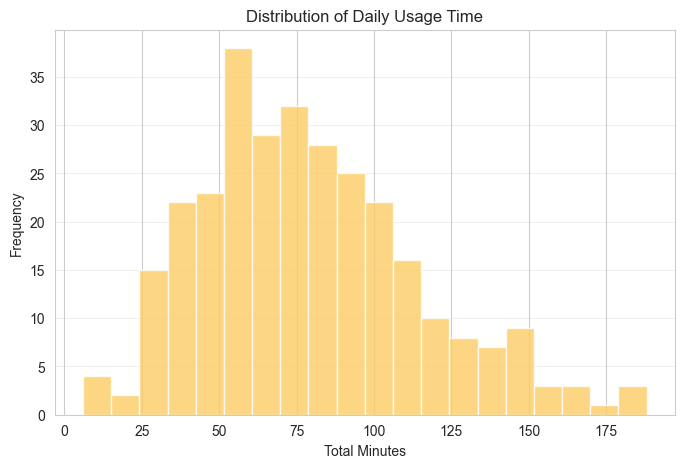

In [41]:
plt.figure(figsize=(8,5))
plt.hist(daily["total_minutes"], bins=20, color=project_color, alpha=0.8)
plt.title("Distribution of Daily Usage Time")
plt.xlabel("Total Minutes")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

Most users spend around 50–100 minutes per day.

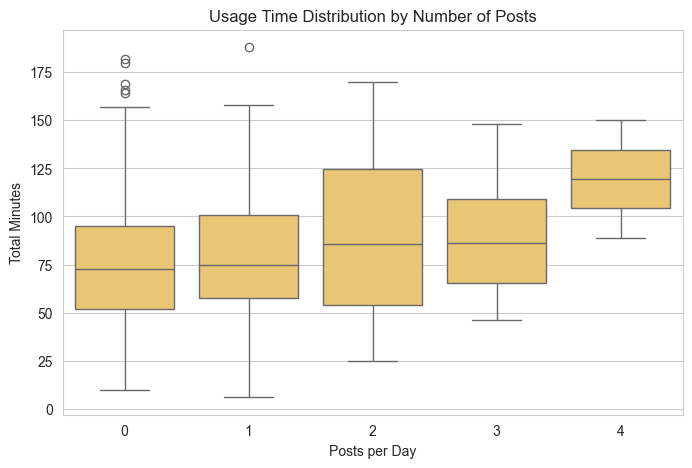

In [42]:
plt.figure(figsize=(8,5))
sb.boxplot(data=daily, x="posts_per_day", y="total_minutes", color=project_color)
plt.title("Usage Time Distribution by Number of Posts")
plt.xlabel("Posts per Day")
plt.ylabel("Total Minutes")
plt.show()

Although there is a slight increase in usage with more posts, the groups overlap, which suggests a weak relationship.

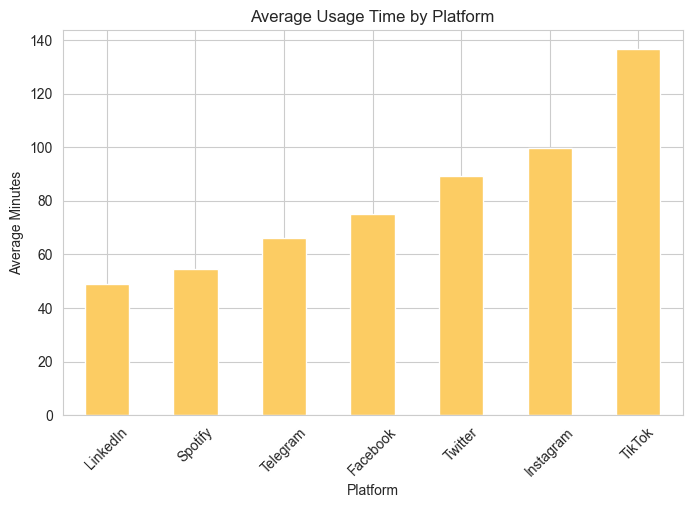

In [43]:
platform_activity = daily.groupby("platform_name")["total_minutes"].mean().sort_values()
plt.figure(figsize=(8,5))
platform_activity.plot(kind="bar", color=project_color)
plt.title("Average Usage Time by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Minutes")
plt.xticks(rotation=45)
plt.show()

Some platforms show higher usage, especially TikTok and Instagram.

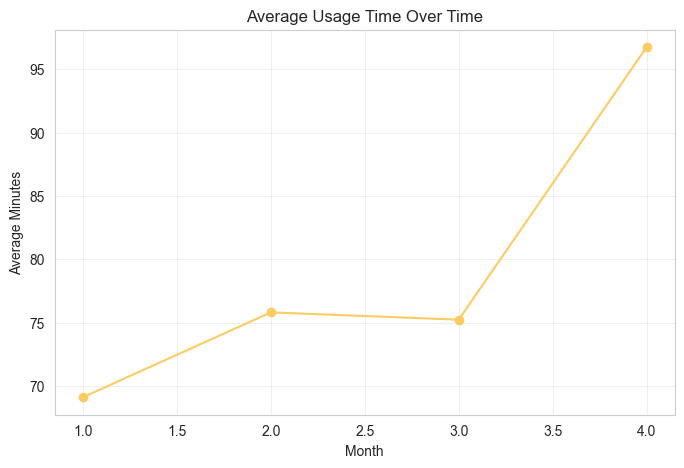

In [44]:
monthly_usage = daily.groupby("month")["total_minutes"].mean()
plt.figure(figsize=(8,5))
monthly_usage.plot(marker="o", color=project_color)
plt.title("Average Usage Time Over Time")
plt.xlabel("Month")
plt.ylabel("Average Minutes")
plt.grid(alpha=0.3)
plt.show()

Month numbers represent the months in the dataset (1 = January, 2 = February, 3 = March, 4 = April).

There is a general increase in usage over time.

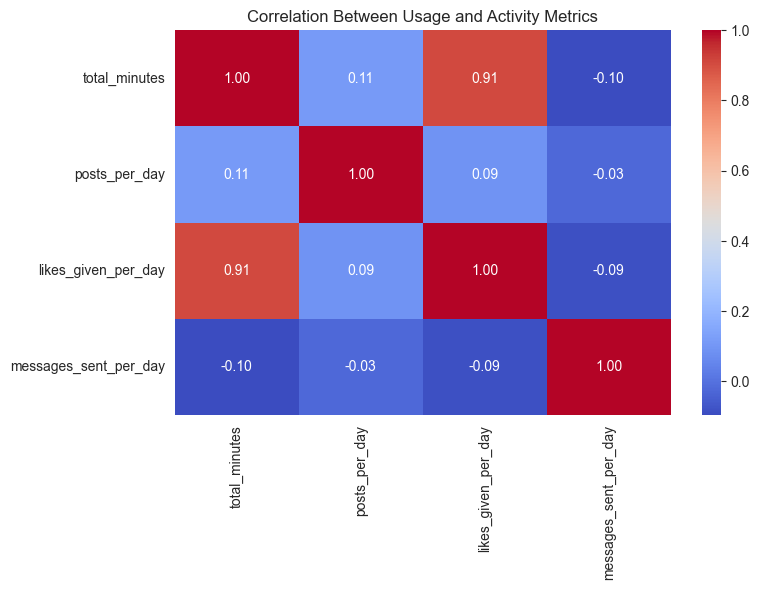

In [45]:
corr = daily[["total_minutes","posts_per_day","likes_given_per_day","messages_sent_per_day"]].corr()
plt.figure(figsize=(8,5))
sb.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Usage and Activity Metrics")
plt.show()

There is a strong relationship between usage time and likes, but weak relationships with other variables.

The visualizations help illustrate patterns in social media usage and user activity.  
The histogram shows how daily usage time is distributed among users, while the boxplot explores the relationship between time spent and posting behavior.  
The bar chart highlights differences between platforms, and the line chart shows trends in usage over time.  

Finally, the heatmap displays the correlation between time spent on social media and different activity metrics.  
Positive values indicate that higher usage time is associated with increased activity levels, while negative values would indicate an inverse relationship.

## Summary and Conclusions

The analysis examined the relationship between time spent on social media and different user activity metrics.

The correlation results show a strong relationship between total usage time and the number of likes given per day, as shown in the heatmap (correlation = 0.91). This suggests that users who spend more time on social media tend to interact more with content by liking posts.

In contrast, the relationship between time spent and posts created per day is very weak (correlation = 0.11), as shown also in the boxplot (Graph 2) Although users who post more may spend slightly more time on the platform, the large overlap between the groups suggests that posting activity does not strongly depend on usage time. 
This indicates that spending more time on social media does not necessarily lead to creating more posts.

The platform comparison shows that TikTok and Instagram have the highest average usage time, while platforms such as LinkedIn and Spotify have lower usage levels (Graph 3).

The distribution of daily usage time shows that most users spend approximately 50–100 minutes per day on social media (Graph 1).

Overall, the results suggest that users who spend more time on social media tend to be more active in giving likes, but not necessarily in creating content or sending messages.